In [1]:
import pandas as pd
import numpy as np

path = '/content/drive/MyDrive/Colab Notebooks/wine.csv'

df = pd.read_csv(path)

df

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,3,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,3,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


In [2]:
df2=df.drop('Wine',axis=1)
df.head()

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [3]:
y=df2['Alcohol']
y.value_counts()

,count
Alcohol,
13.05,6
12.37,6
12.08,5
12.29,4
12.00,3
...,...
12.82,1
12.20,1
14.16,1


In [4]:
X=df2.drop('Alcohol',axis=1)
X.head()

,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [5]:
Y = y.values

In [6]:
X = X.values

In [7]:
from sklearn.model_selection import train_test_split
X_train,X_test, y_train,y_test = train_test_split(X,Y,test_size=0.2,random_state=0)

In [8]:
#Standardization
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

y_scaler = StandardScaler()
y_train = y_scaler.fit_transform(y_train.reshape(-1,1))
y_test = y_scaler.transform(y_test.reshape(-1,1))

In [9]:
#Defining the model

from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import SGD,Adam

model = Sequential()

model.add(Dense(8,input_shape=(X.shape[1],),activation='relu'))
model.add(Dense(30,activation='relu'))
model.add(Dense(30,activation='relu'))
model.add(Dense(1))

model.compile(optimizer = 'adam', loss = 'mse', metrics = ['mse'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │           270 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 30)             │           930 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,335 (5.21 KB)

 Trainable params: 1,335 (5.21 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model_history = model.fit(x=X_train, y=y_train, epochs=30, batch_size=32,validation_data= (X_test,y_test))
y_pred = model.predict(X_test)

#y값 스케일링 복원
y_pred = y_scaler.inverse_transform(y_pred)
y_test_original = y_scaler.inverse_transform(y_test)

Epoch 1/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 110ms/step - loss: 1.2398 - mse: 1.2398 - val_loss: 1.1201 - val_mse: 1.1201
Epoch 2/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 1.0365 - mse: 1.0365 - val_loss: 0.9986 - val_mse: 0.9986
Epoch 3/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.9323 - mse: 0.9323 - val_loss: 0.9073 - val_mse: 0.9073
Epoch 4/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.8495 - mse: 0.8495 - val_loss: 0.8222 - val_mse: 0.8222
Epoch 5/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.7823 - mse: 0.7823 - val_loss: 0.7439 - val_mse: 0.7439
Epoch 6/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - loss: 0.7389 - mse: 0.7389 - val_loss: 0.6749 - val_mse: 0.6749
Epoch 7/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 0.7000 - mse: 0.7000 - val_loss: 0.6207 - val_mse: 0.6207
Epoch 8/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 0.6583 - mse: 0.6583 - val_loss: 0.5843 - val_mse: 0.5843
Epoch 9/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.6243 - mse: 0.6243 -

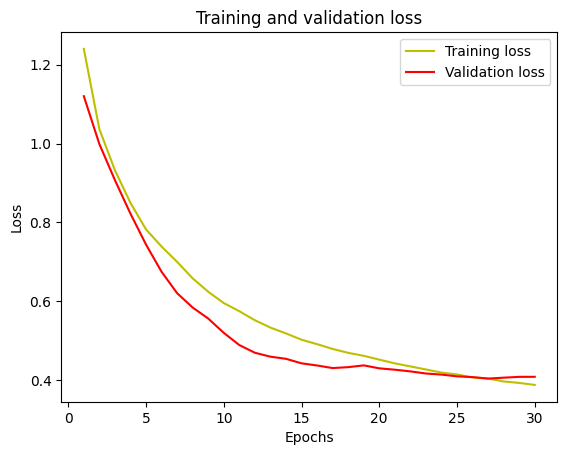

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

loss = model_history.history['loss']
val_loss = model_history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [12]:
#MSE,MAE,R2 of the predicted values
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("MSE:", mean_squared_error(y_test_original, y_pred))
print("MAE:", mean_absolute_error(y_test_original, y_pred))
print("R2:", r2_score(y_test_original, y_pred))

MSE: 0.2644087074890839
MAE: 0.3913144567277697
R2: 0.6132761480092941


In [13]:
model.evaluate(X_test, y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.4087 - mse: 0.4087


[0.40870460867881775, 0.40870460867881775]